In [34]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [40]:
data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Project 3 NLP/training_data.csv",
                        sep="\t", header=None, names=["label", "text"])
data_test = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Project 3 NLP/testing_data.csv",
                       sep="\t", header=None, names=["label", "text"])

# data = pd.read_csv(r"\dataset\training_data.csv", sep="\t", header=None, names=["label", "text"])

In [41]:
df = data.copy()

In [ ]:
df.head()

,label,text
0,0,donald trump sends out embarrassing new year‚s...
1,0,drunk bragging trump staffer started russian c...
2,0,sheriff david clarke becomes an internet joke ...
3,0,trump is so obsessed he even has obama‚s name ...
4,0,pope francis just called out donald trump duri...


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34152 entries, 0 to 34151
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   34152 non-null  int64 
 1   text    34152 non-null  object
dtypes: int64(1), object(1)
memory usage: 533.8+ KB


In [ ]:
df.text[0]

'donald trump sends out embarrassing new year‚s eve message; this is disturbing'

In [ ]:
df.label.value_counts() #balanced dataset

,count
label,
0,17572
1,16580


In [42]:
df = df.drop_duplicates()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32206 entries, 0 to 34151
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   32206 non-null  int64 
 1   text    32206 non-null  object
dtypes: int64(1), object(1)
memory usage: 754.8+ KB


In [43]:
# Removing punctuations
X = df.text
X.replace("[^a-zA-Z]"," ",regex=True, inplace=True)
X[0]

'donald trump sends out embarrassing new year s eve message  this is disturbing'

In [44]:
from sklearn.model_selection import train_test_split

y = df.label

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# COUNT VECTORIZER

In [45]:
## implement BAG OF WORDS
countvector=CountVectorizer(ngram_range=(1,2), stop_words="english")
X_train_vectorized=countvector.fit_transform(X_train)
X_test_vectorized=countvector.transform(X_test)

In [ ]:
# implement RandomForest Classifier
randomclassifier=RandomForestClassifier(n_estimators=200,criterion='entropy')
randomclassifier.fit(X_train_vectorized,y_train)

RandomForestClassifier(criterion='entropy', n_estimators=200)

In [ ]:
## Predict for the Test Dataset
predictions = randomclassifier.predict(X_test_vectorized)

In [ ]:
matrix=confusion_matrix(y_test,predictions)
print(matrix)
score=accuracy_score(y_test,predictions)
print(score)
report=classification_report(y_test,predictions)
print(report)

[[3304  211]
 [ 298 3018]]
0.9254867515737081
              precision    recall  f1-score   support

           0       0.92      0.94      0.93      3515
           1       0.93      0.91      0.92      3316

    accuracy                           0.93      6831
   macro avg       0.93      0.93      0.93      6831
weighted avg       0.93      0.93      0.93      6831



In [ ]:
#results =pd.DataFrame({"Accuracy":[score]}, index=["CV(1,1)+RF200"])
#results

In [ ]:
#results.loc["CV(1,2)+RF200"] = score
#results

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.naive_bayes import MultinomialNB

models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        criterion="entropy",
        random_state=42
    ),

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Multinomial Naive Bayes": MultinomialNB(),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        eval_metric="logloss",
        random_state=42
    ),
}


results = pd.DataFrame(columns=["Accuracy"])

for model_name, model in models.items():

    # Train model
    model.fit(X_train_vectorized, y_train)

    # Make predictions
    y_pred = model.predict(X_test_vectorized)

    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)

    # Add accuracy to results DataFrame
    results.loc[model_name, "Accuracy"] = accuracy


# Convert the accuracy column to numeric
results["Accuracy"] = pd.to_numeric(results["Accuracy"])

# Sort from highest to lowest accuracy
results = results.sort_values(
    by="Accuracy",
    ascending=False
)

print(results)

                         Accuracy
Multinomial Naive Bayes  0.937442
Logistic Regression      0.929991
Random Forest            0.917572
XGBoost                  0.899876


In [ ]:
# results_cv_12 = results

In [ ]:
#print(results_cv_11)
#print(results_cv_22)
print(results_cv_12)

                         Accuracy
Multinomial Naive Bayes  0.937442
Logistic Regression      0.929991
Random Forest            0.917572
XGBoost                  0.899876


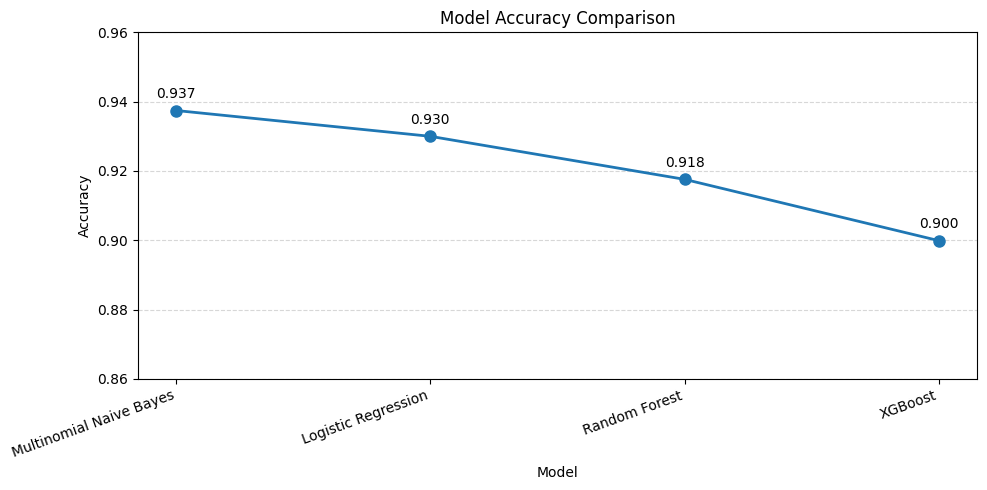

In [ ]:
plot_df = results_cv_12

plt.figure(figsize=(10, 5))

plt.plot(
    plot_df.index,
    plot_df["Accuracy"],
    marker="o",
    markersize=8,
    linewidth=2
)

# Add the value above each point
for model, accuracy in zip(plot_df.index, plot_df["Accuracy"]):
    plt.annotate(
        f"{accuracy:.3f}",
        xy=(model, accuracy),
        xytext=(0, 9),
        textcoords="offset points",
        ha="center"
    )

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0.86, 0.96)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()

plt.show()

In [49]:
#check overfitting predicting X_train
multinb = MultinomialNB()
multinb.fit(X_train_vectorized,y_train)

predictions = multinb.predict(X_train_vectorized)
score_train =accuracy_score(y_train,predictions)


In [50]:
print(f"Train Accuracy: {score_train:.4}")
print(f"Test Accuracy: {results_cv_12.iloc[0]}")

Train Accuracy: 0.9857
Test Accuracy: Accuracy    0.937442
Name: Multinomial Naive Bayes, dtype: float64


# TF-IDF

In [ ]:
## implement BAG OF WORDS
tfidfvector=TfidfVectorizer(ngram_range=(1,2), stop_words="english")
X_train_vectorized=tfidfvector.fit_transform(X_train)
X_test_vectorized=tfidfvector.transform(X_test)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.naive_bayes import MultinomialNB

models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        criterion="entropy",
        random_state=42
    ),

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Multinomial Naive Bayes": MultinomialNB(),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        eval_metric="logloss",
        random_state=42
    ),
}


results = pd.DataFrame(columns=["Accuracy"])

for model_name, model in models.items():

    # Train model
    model.fit(X_train_vectorized, y_train)

    # Make predictions
    y_pred = model.predict(X_test_vectorized)

    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)

    # Add accuracy to results DataFrame
    results.loc[model_name, "Accuracy"] = accuracy


# Convert the accuracy column to numeric
results["Accuracy"] = pd.to_numeric(results["Accuracy"])

# Sort from highest to lowest accuracy
results = results.sort_values(
    by="Accuracy",
    ascending=False
)

print(results)

                         Accuracy
Multinomial Naive Bayes  0.934648
Logistic Regression      0.925489
Random Forest            0.899410
XGBoost                  0.855635


In [ ]:
results_tfidf_12 = results

In [ ]:
#print(results_tfidf_11)
#print(results_tfidf_22)
print(results_tfidf_12)

                         Accuracy
Multinomial Naive Bayes  0.934648
Logistic Regression      0.925489
Random Forest            0.899410
XGBoost                  0.855635


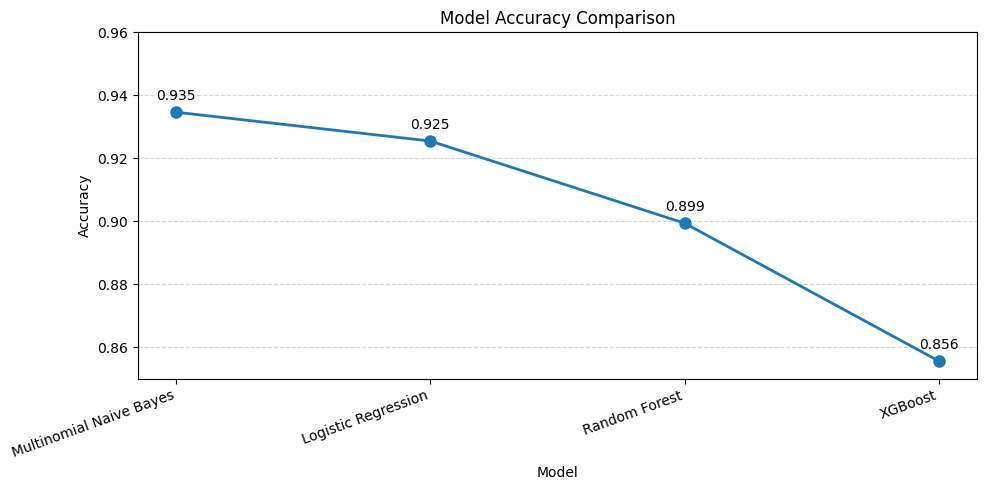

In [ ]:
plot_df = results_tfidf_12

plt.figure(figsize=(10, 5))

plt.plot(
    plot_df.index,
    plot_df["Accuracy"],
    marker="o",
    markersize=8,
    linewidth=2
)

# Add the value above each point
for model, accuracy in zip(plot_df.index, plot_df["Accuracy"]):
    plt.annotate(
        f"{accuracy:.3f}",
        xy=(model, accuracy),
        xytext=(0, 9),
        textcoords="offset points",
        ha="center"
    )

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0.85, 0.96)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()

plt.show()

In [ ]:
#check overfitting predicting X_train

multinb = MultinomialNB()
multinb.fit(X_train_vectorized,y_train)

predictions = multinb.predict(X_train_vectorized)
score_train =accuracy_score(y_train,predictions)


In [ ]:
print(f"Train Accuracy: {score_train:.4}")
print(f"Test Accuracy: {results_tfidf_12.iloc[0]}")

Train Accuracy: 0.9811
Test Accuracy: Accuracy    0.934648
Name: Multinomial Naive Bayes, dtype: float64


# Comparison between vectorizers and between models

                           TF-IDF  CountVectorizer
Multinomial Naive Bayes  0.934648         0.937442
Logistic Regression      0.925489         0.929991
Random Forest            0.899410         0.917572
XGBoost                  0.855635         0.899876


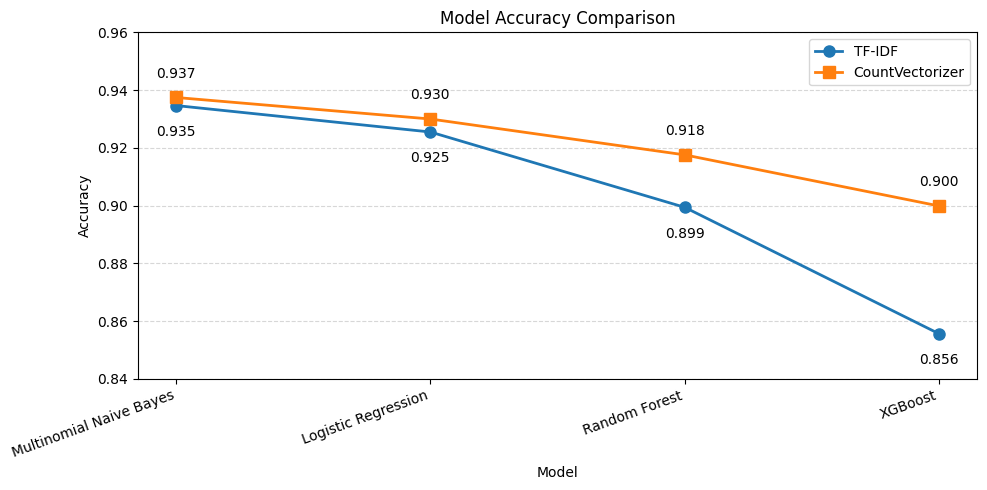

In [ ]:
plot_df = pd.concat(
    [
        results_tfidf_12["Accuracy"].rename("TF-IDF"),
        results_cv_12["Accuracy"].rename("CountVectorizer")
    ],
    axis=1
)

# Sort models by their highest result
plot_df = plot_df.assign(
    Best_Accuracy=plot_df[["TF-IDF", "CountVectorizer"]].max(axis=1)
).sort_values(
    by="Best_Accuracy",
    ascending=False
).drop(columns="Best_Accuracy")

print(plot_df)

plt.figure(figsize=(10, 5))

plt.plot(
    plot_df.index,
    plot_df["TF-IDF"],
    marker="o",
    markersize=8,
    linewidth=2,
    label="TF-IDF"
)

plt.plot(
    plot_df.index,
    plot_df["CountVectorizer"],
    marker="s",
    markersize=8,
    linewidth=2,
    label="CountVectorizer"
)

# TF-IDF values below
for model, accuracy in plot_df["TF-IDF"].dropna().items():
    plt.annotate(
        f"{accuracy:.3f}",
        xy=(model, accuracy),
        xytext=(0, -14),
        textcoords="offset points",
        ha="center",
        va="top"
    )

# CountVectorizer values above
for model, accuracy in plot_df["CountVectorizer"].dropna().items():
    plt.annotate(
        f"{accuracy:.3f}",
        xy=(model, accuracy),
        xytext=(0, 12),
        textcoords="offset points",
        ha="center",
        va="bottom"
    )

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0.84, 0.96)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks(rotation=20, ha="right")
plt.legend()
plt.tight_layout()

plt.show()

# Comparison between hyperparameter ngram_range

In [ ]:
ngram_range11 = results_cv_11.loc["Logistic Regression", "Accuracy"]
ngram_range22 = results_cv_22.loc["Logistic Regression", "Accuracy"]
ngram_range12 = results_cv_12.loc["Logistic Regression", "Accuracy"]
print(f"{ngram_range11:.4} {ngram_range22:.4} {ngram_range12:.4}")

0.9368 0.8706 0.9412


In [ ]:
ngram_range11 = results_tfidf_11.loc["Logistic Regression", "Accuracy"]
ngram_range22 = results_tfidf_22.loc["Logistic Regression", "Accuracy"]
ngram_range12 = results_tfidf_12.loc["Logistic Regression", "Accuracy"]
print(f"{ngram_range11:.4} {ngram_range22:.4} {ngram_range12:.4}")

0.9334 0.8639 0.9318


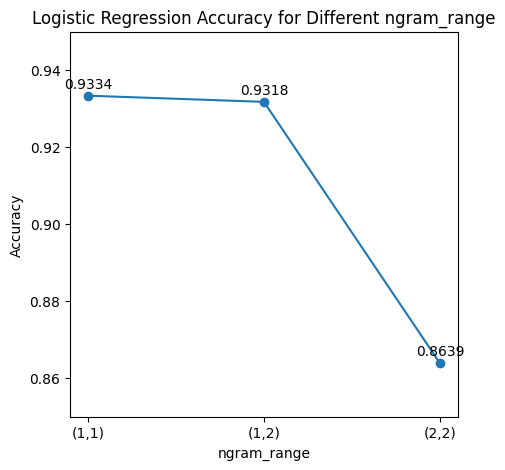

In [ ]:
ngram_labels = ["(1,1)", "(1,2)", "(2,2)"]
accuracies = [ngram_range11, ngram_range12, ngram_range22]

plt.figure(figsize=(5,5))
plt.plot(ngram_labels, accuracies, marker="o")

# add values on the points
for x, y in zip(ngram_labels, accuracies):
    plt.text(x, y + 0.002, f"{y:.4f}", ha="center")

plt.title("Logistic Regression Accuracy for Different ngram_range")
plt.xlabel("ngram_range")
plt.ylabel("Accuracy")
plt.ylim(0.85, 0.95)

plt.show()

# BEST MODEL + VECTORIZER: LOGISTIC REGRESSION + CV

In [53]:
df_test = data_test.copy()

In [54]:
# Removing punctuations
XX = df_test.text
XX.replace("[^a-zA-Z]"," ",regex=True, inplace=True)
XX[0]

'copycat muslim terrorist arrested with assault weapons'

In [55]:
## implement BAG OF WORDS
XX_vectorized = countvector.transform(XX)
test_predictions = multinb.predict(XX_vectorized)


In [56]:
data_test.label = test_predictions
data_test

,label,text
0,0,copycat muslim terrorist arrested with assault...
1,0,wow! chicago protester caught on camera admits...
2,1,germany's fdp look to fill schaeuble's big shoes
3,0,mi school sends welcome back packet warning ki...
4,1,u.n. seeks 'massive' aid boost amid rohingya '...
...,...,...
9979,0,boom! fox news leftist chris wallace attempts ...
9980,0,here it is: list of democrat hypocrites who vo...
9981,1,new fires ravage rohingya villages in northwes...
9982,0,meals on wheels shuts the lyin‚ lefties up wit...


In [57]:
import csv
data_test.to_csv("testing_data_pred.csv", sep="\t", index=False, header=False, quoting=csv.QUOTE_MINIMAL)

In [58]:
from google.colab import files
files.download("testing_data_pred.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

tabla comparacion de lo mejor entre 2 vectorizers, el mejor resultado de cv y tfidf, en mismo grafico
conclusion de mejor vectorizador y mejor model.

tabla comparacion de nrange: (1,1)(1,2)(2,2) en un solo vectorizador. para ver en que modelos como fluctua y que nrange es mejor.


dropando duplicados

lemmatization
